<a href="https://colab.research.google.com/github/shumailab489/AgriVerse/blob/main/Screens4Life_Assessment_Colab_Notebook_Updated_Executed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Screens 4 Life - CW3 Programming Solution

This notebook is designed for **Google Colab** and follows the assessment brief:
- load the CSV and Excel files
- clean and combine the data
- perform EDA with visualisations
- build and compare **two analytical models**
- produce outputs that can be copied into the report appendix

> Before running: upload `Screens4Life_0F.csv` and `Screens4Life_1F.xlsx` to the Colab session.

In [ ]:
# =========================
# 1. Import libraries
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, log_loss, classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Make charts display neatly in Colab
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

print("Libraries imported successfully.")

Libraries imported successfully.


## 1A. Libraries used and why

This notebook uses the following Python libraries:

- **pandas**: to load the CSV and Excel files, combine them, clean the data, and produce summary tables.
- **numpy**: to support numerical operations where needed.
- **matplotlib**: to create the charts required for the descriptive analysis section.
- **scikit-learn**: to prepare the data for modelling, split the data into training and testing sets, build the two analytical models, and evaluate model performance.

These libraries were selected because they are widely used, well documented, and suitable for a maintainable HR analytics workflow. In a real business setting, using standard libraries also makes it easier for future team members to understand, test, and extend the code.

## 1B. Pseudocode

```text
START

IMPORT required Python libraries

LOAD Factory 0 data from CSV file
LOAD Factory 1 data from Excel file

STANDARDISE column names in both datasets
COMBINE both datasets into one table

CREATE unique EmployeeID column
SET EmployeeID as the main index

CHECK data types, missing values, duplicates, and inconsistent categories

CLEAN the data by:
    - standardising text categories
    - fixing coded values in ShiftFlexibility
    - trimming spaces
    - removing duplicate rows
    - converting numeric fields to numeric format
    - capping extreme outliers with IQR rules

PERFORM EDA by calculating:
    - average years of experience
    - average defect rate
    - average age
    - distributions for units produced, punctuality, salary
    - category counts for shift flexibility, ethnicity, and gender
    - correlation table for numeric variables

PREPARE modelling data:
    - separate features and target
    - identify numeric and categorical columns
    - create preprocessing pipelines
    - split into training and test sets

TRAIN Logistic Regression model
EVALUATE Logistic Regression using accuracy, precision, recall, F1-score, and log loss

TRAIN Random Forest model
EVALUATE Random Forest using accuracy, precision, recall, F1-score, and log loss

COMPARE both models in a summary table

CHECK descriptive fairness patterns across gender, ethnicity, and age bands

EXPORT cleaned data and model comparison results

END
```

## 2. Load the two datasets

In Colab, upload the two files first:
- `Screens4Life_0F.csv`
- `Screens4Life_1F.xlsx`

This code reads both files into pandas DataFrames.

In [ ]:
# =========================
# 2. Load data
# =========================
csv_file = "Screens4Life_0F.csv"
excel_file = "Screens4Life_1F.xlsx"

df_csv = pd.read_csv(csv_file)
df_excel = pd.read_excel(excel_file)

print("CSV shape:", df_csv.shape)
print("Excel shape:", df_excel.shape)

display(df_csv.head())
display(df_excel.head())

CSV shape: (188, 13)
Excel shape: (212, 13)


,Factory_Loc,UnitsProducedPerHour,DefectRate(%),OnTimeCompletion(%),YearsExperience,AbsenteeismRate(days/year),Punctuality(%),ShiftFlexibility,CurrentSalary,Age,Gender,Ethnicity,Raise (1=Yes; 0=Redundancy)
0,0,56.476885,3.636571,85.714242,5.0,1.274887,95.988581,Medium,5814,36,Female,Mixed,0
1,0,45.305256,4.401825,80.863198,10.0,7.200365,92.445494,High,5552,55,Female,NaN,0
2,0,55.425600,4.609582,97.822862,29.0,6.411476,93.952643,Medium,5405,43,Male,Black,1
3,0,45.365823,2.801041,90.554022,29.0,6.939484,90.013658,High,5941,28,Female,Asian,0
4,0,45.342702,2.756823,99.859296,29.0,5.427244,96.563683,Medium,5778,52,Male,Black,1


,Factory_Loc,UnitsProducedPerHour,DefectRate(%),OnTimeCompletion(%),YearsExperience,AbsenteeismRate(days/year),Punctuality(%),ShiftFlexibility,CurrentSalary,Age,Gender,Ethnicity,Raise (1=Yes; 0=Redundancy)
0,1,54.967142,4.448179,99.243451,21,1.106317,94.955067,Medium,4786,32.0,Male,NaN,1
1,1,48.617357,3.833459,87.497412,20,8.464523,99.052446,High,7415,38.0,Other,White,0
2,1,65.230299,3.661178,97.371983,5,3.972873,88.224106,Low,5191,46.0,Male,Black,0
3,1,47.658466,2.117710,84.471917,22,7.972954,85.467747,Medium,6996,42.0,Male,Mixed,0
4,1,47.658630,1.821163,99.264451,15,1.499174,88.933961,Medium,2964,50.0,Other,Mixed,1


## 2A. How the files are treated and overall procedure

The two factories store the same HR data in different formats, so the first task is to read both sources correctly:

- the **CSV file** is loaded with `pd.read_csv()`
- the **Excel file** is loaded with `pd.read_excel()`

After loading, both datasets are standardised so that the column names match. This is important because the original files use labels such as `Factory_Loc` and `Raise (1=Yes; 0=Redundancy)`, which need to be renamed into consistent variable names before the files can be merged safely.

The overall ETL-style procedure used in this notebook is:

1. **Extract** the two files from their original formats.
2. **Transform** the data by renaming columns, cleaning categories, converting numeric fields, handling duplicates, and capping outliers.
3. **Load** the cleaned combined data into one DataFrame for EDA and modelling.

This approach improves consistency, reduces manual handling, and supports future reuse by other colleagues.

## 3. Check column names and standardise them

The uploaded files use the same structure, but the column names are slightly different from the wording in the brief.
We standardise them so the rest of the notebook is clean and consistent.

In [ ]:
# =========================
# 3. Standardise column names
# =========================
rename_map = {
    "Factory_Loc": "FactoryLocation",
    "UnitsProducedPerHour": "UnitsProducedPerHour",
    "DefectRate(%)": "DefectRatePct",
    "OnTimeCompletion(%)": "OnTimeCompletionPct",
    "YearsExperience": "YearsExperience",
    "AbsenteeismRate(days/year)": "AbsenteeismRateDaysPerYear",
    "Punctuality(%)": "PunctualityPct",
    "ShiftFlexibility": "ShiftFlexibility",
    "CurrentSalary": "CurrentSalary",
    "Age": "Age",
    "Gender": "Gender",
    "Ethnicity": "Ethnicity",
    "Raise (1=Yes; 0=Redundancy)": "Raise"
}

df_csv = df_csv.rename(columns=rename_map)
df_excel = df_excel.rename(columns=rename_map)

print("CSV columns:")
print(df_csv.columns.tolist())
print("\nExcel columns:")
print(df_excel.columns.tolist())

CSV columns:
['FactoryLocation', 'UnitsProducedPerHour', 'DefectRatePct', 'OnTimeCompletionPct', 'YearsExperience', 'AbsenteeismRateDaysPerYear', 'PunctualityPct', 'ShiftFlexibility', 'CurrentSalary', 'Age', 'Gender', 'Ethnicity', 'Raise']

Excel columns:
['FactoryLocation', 'UnitsProducedPerHour', 'DefectRatePct', 'OnTimeCompletionPct', 'YearsExperience', 'AbsenteeismRateDaysPerYear', 'PunctualityPct', 'ShiftFlexibility', 'CurrentSalary', 'Age', 'Gender', 'Ethnicity', 'Raise']


## 4. Combine the datasets and create an ID column

The brief asks for the HR data to be indexed on an ID column.
As the supplied files do not contain a unique employee ID, this notebook creates one after merging the two files.

In [ ]:
# =========================
# 4. Combine data and create EmployeeID
# =========================
df = pd.concat([df_csv, df_excel], ignore_index=True)

# Create a unique ID column
df.insert(0, "EmployeeID", range(1, len(df) + 1))

# Set the ID as the index for inspection
df = df.set_index("EmployeeID")

print("Combined dataset shape:", df.shape)
display(df.head())

Combined dataset shape: (400, 13)


,FactoryLocation,UnitsProducedPerHour,DefectRatePct,OnTimeCompletionPct,YearsExperience,AbsenteeismRateDaysPerYear,PunctualityPct,ShiftFlexibility,CurrentSalary,Age,Gender,Ethnicity,Raise
EmployeeID,,,,,,,,,,,,,
1,0,56.476885,3.636571,85.714242,5.0,1.274887,95.988581,Medium,5814,36.0,Female,Mixed,0
2,0,45.305256,4.401825,80.863198,10.0,7.200365,92.445494,High,5552,55.0,Female,NaN,0
3,0,55.425600,4.609582,97.822862,29.0,6.411476,93.952643,Medium,5405,43.0,Male,Black,1
4,0,45.365823,2.801041,90.554022,29.0,6.939484,90.013658,High,5941,28.0,Female,Asian,0
5,0,45.342702,2.756823,99.859296,29.0,5.427244,96.563683,Medium,5778,52.0,Male,Black,1


## 5. Initial data quality checks

This section checks:
- missing values
- duplicates
- data types
- category inconsistencies

In [ ]:
# =========================
# 5. Initial data quality checks
# =========================
print("Data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nDuplicate rows:", df.duplicated().sum())

print("\nUnique values in ShiftFlexibility:")
display(df["ShiftFlexibility"].value_counts(dropna=False))

print("\nUnique values in Gender:")
display(df["Gender"].value_counts(dropna=False))

print("\nUnique values in Ethnicity:")
display(df["Ethnicity"].value_counts(dropna=False))

Data types:


,0
FactoryLocation,int64
UnitsProducedPerHour,float64
DefectRatePct,float64
OnTimeCompletionPct,float64
YearsExperience,float64
AbsenteeismRateDaysPerYear,float64
PunctualityPct,float64
ShiftFlexibility,object
CurrentSalary,int64
Age,float64



Missing values:


,0
Gender,8
Ethnicity,7
Age,3
OnTimeCompletionPct,3
UnitsProducedPerHour,2
DefectRatePct,1
YearsExperience,1
FactoryLocation,0
AbsenteeismRateDaysPerYear,0
CurrentSalary,0



Duplicate rows: 0

Unique values in ShiftFlexibility:


,count
ShiftFlexibility,
Medium,149
High,122
Low,122
H,3
L,2
M,2



Unique values in Gender:


,count
Gender,
Male,188
Female,170
Other,34
NaN,8



Unique values in Ethnicity:


,count
Ethnicity,
Mixed,108
Asian,105
Black,93
White,87
NaN,7


## 6. Clean the data

Cleaning performed:
1. fix inconsistent shift flexibility labels (`H`, `M`, `L`)
2. trim text fields
3. keep missing values for imputation in the modelling pipeline
4. remove duplicate rows if found
5. winsorise numeric outliers using the IQR rule to reduce extreme influence

In [ ]:
# =========================
# 6. Data cleaning
# =========================
df_clean = df.copy()

# Standardise categorical text
for col in ["Gender", "Ethnicity", "ShiftFlexibility"]:
    df_clean[col] = df_clean[col].astype("object")

# Fix short codes in ShiftFlexibility
df_clean["ShiftFlexibility"] = df_clean["ShiftFlexibility"].replace({
    "H": "High",
    "M": "Medium",
    "L": "Low"
})

# Strip spaces from text columns
for col in ["Gender", "Ethnicity", "ShiftFlexibility"]:
    df_clean[col] = df_clean[col].apply(lambda x: x.strip() if isinstance(x, str) else x)

# Remove duplicate rows if present
df_clean = df_clean.drop_duplicates()

# Convert numeric columns explicitly
numeric_cols = [
    "FactoryLocation", "UnitsProducedPerHour", "DefectRatePct",
    "OnTimeCompletionPct", "YearsExperience", "AbsenteeismRateDaysPerYear",
    "PunctualityPct", "CurrentSalary", "Age", "Raise"
]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")

# Handle outliers with IQR capping (winsorisation)
continuous_cols = [
    "UnitsProducedPerHour", "DefectRatePct", "OnTimeCompletionPct",
    "YearsExperience", "AbsenteeismRateDaysPerYear",
    "PunctualityPct", "CurrentSalary", "Age"
]

for col in continuous_cols:
    q1 = df_clean[col].quantile(0.25)
    q3 = df_clean[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print("Cleaned dataset shape:", df_clean.shape)
print("\nMissing values after cleaning (before model imputation):")
display(df_clean.isnull().sum().sort_values(ascending=False))

print("\nShiftFlexibility after standardisation:")
display(df_clean["ShiftFlexibility"].value_counts(dropna=False))

Cleaned dataset shape: (400, 13)

Missing values after cleaning (before model imputation):


,0
Gender,8
Ethnicity,7
Age,3
OnTimeCompletionPct,3
UnitsProducedPerHour,2
DefectRatePct,1
YearsExperience,1
FactoryLocation,0
AbsenteeismRateDaysPerYear,0
CurrentSalary,0



ShiftFlexibility after standardisation:


,count
ShiftFlexibility,
Medium,151
High,125
Low,124


## 7. Descriptive analysis and EDA

The brief specifically requires:
- average years of experience
- distribution of units produced per hour
- average defect rate
- distribution of punctuality
- counts of low / medium / high shift flexibility
- distribution of current salary

Optional additions:
- average age
- ethnicity distribution
- gender distribution

In [ ]:
# =========================
# 7. Summary statistics required by the brief
# =========================
avg_experience = df_clean["YearsExperience"].mean()
avg_defect_rate = df_clean["DefectRatePct"].mean()
avg_age = df_clean["Age"].mean()

print(f"Average years of experience: {avg_experience:.2f}")
print(f"Average defect rate: {avg_defect_rate:.2f}%")
print(f"Average age of employees: {avg_age:.2f}")

Average years of experience: 14.16
Average defect rate: 2.77%
Average age of employees: 39.09


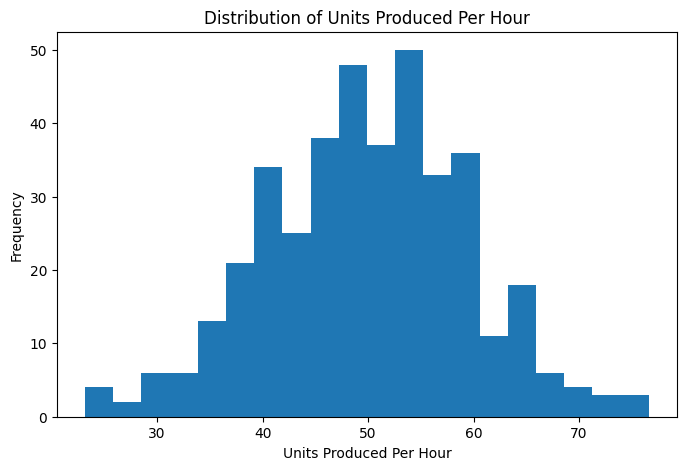

In [ ]:
# Distribution of Units Produced Per Hour
plt.figure()
plt.hist(df_clean["UnitsProducedPerHour"].dropna(), bins=20)
plt.title("Distribution of Units Produced Per Hour")
plt.xlabel("Units Produced Per Hour")
plt.ylabel("Frequency")
plt.show()

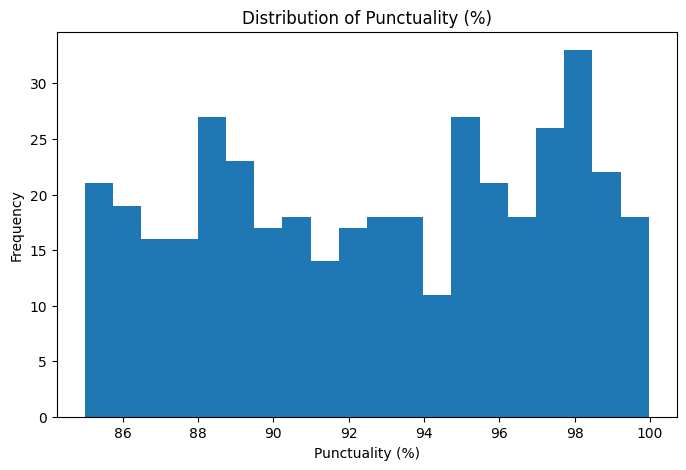

In [ ]:
# Distribution of Punctuality
plt.figure()
plt.hist(df_clean["PunctualityPct"].dropna(), bins=20)
plt.title("Distribution of Punctuality (%)")
plt.xlabel("Punctuality (%)")
plt.ylabel("Frequency")
plt.show()

,count
ShiftFlexibility,
Medium,151
High,125
Low,124


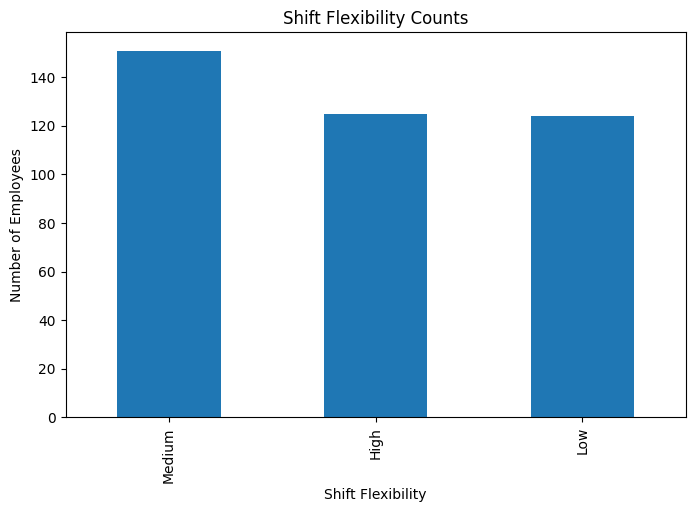

In [ ]:
# Shift Flexibility counts
shift_counts = df_clean["ShiftFlexibility"].value_counts(dropna=False)
display(shift_counts)

plt.figure()
shift_counts.plot(kind="bar")
plt.title("Shift Flexibility Counts")
plt.xlabel("Shift Flexibility")
plt.ylabel("Number of Employees")
plt.show()

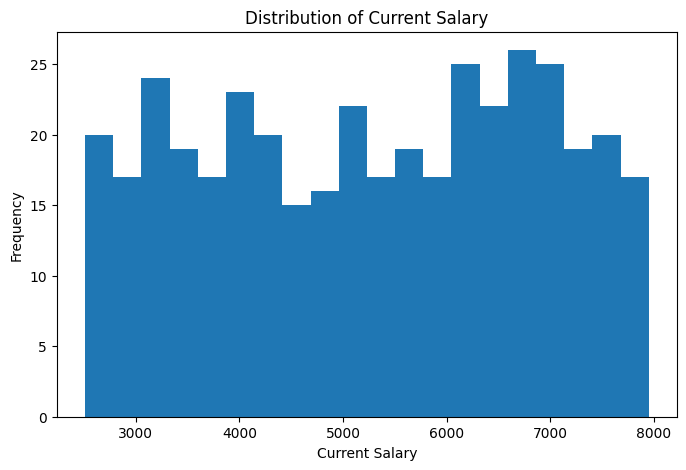

In [ ]:
# Distribution of Current Salary
plt.figure()
plt.hist(df_clean["CurrentSalary"].dropna(), bins=20)
plt.title("Distribution of Current Salary")
plt.xlabel("Current Salary")
plt.ylabel("Frequency")
plt.show()

,count
Ethnicity,
Mixed,108
Asian,105
Black,93
White,87
NaN,7


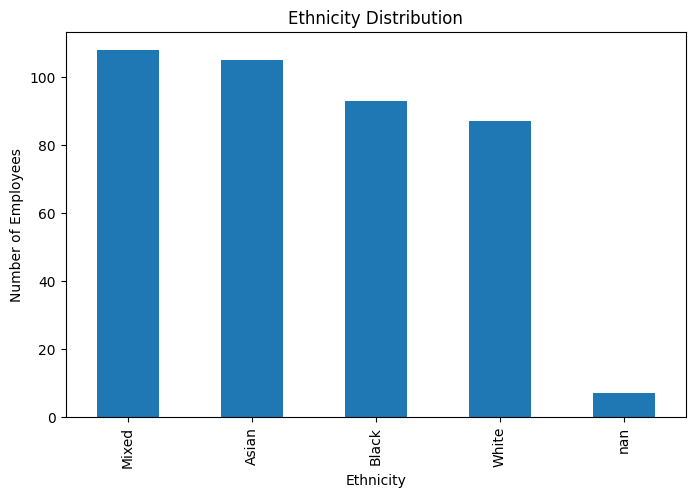

In [ ]:
# Optional: Ethnicity distribution
ethnicity_counts = df_clean["Ethnicity"].value_counts(dropna=False)
display(ethnicity_counts)

plt.figure()
ethnicity_counts.plot(kind="bar")
plt.title("Ethnicity Distribution")
plt.xlabel("Ethnicity")
plt.ylabel("Number of Employees")
plt.show()

,count
Gender,
Male,188
Female,170
Other,34
NaN,8


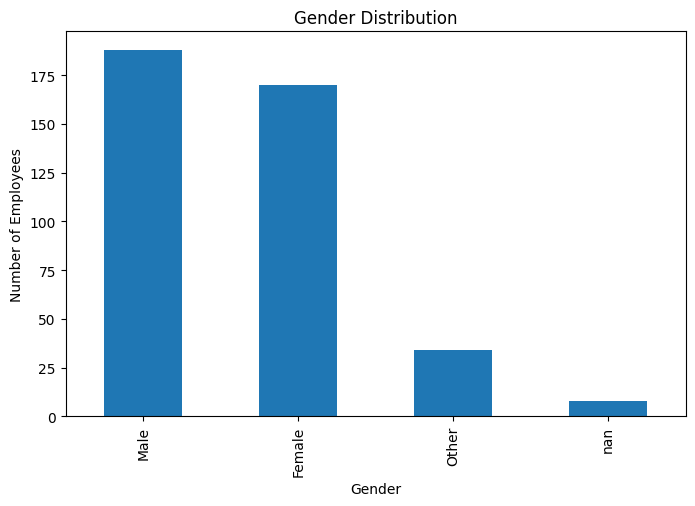

In [ ]:
# Optional: Gender distribution
gender_counts = df_clean["Gender"].value_counts(dropna=False)
display(gender_counts)

plt.figure()
gender_counts.plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Employees")
plt.show()

In [ ]:
# Correlation table for numeric variables
corr = df_clean.select_dtypes(include=["int64", "float64"]).corr()
display(corr.round(2))

,FactoryLocation,UnitsProducedPerHour,DefectRatePct,OnTimeCompletionPct,YearsExperience,AbsenteeismRateDaysPerYear,PunctualityPct,CurrentSalary,Age,Raise
FactoryLocation,1.00,-0.09,0.02,-0.08,0.06,-0.07,-0.05,-0.03,0.07,-0.02
UnitsProducedPerHour,-0.09,1.00,-0.06,-0.03,0.04,0.06,0.02,-0.06,0.03,0.31
DefectRatePct,0.02,-0.06,1.00,-0.04,-0.02,-0.00,-0.05,0.04,0.02,-0.50
OnTimeCompletionPct,-0.08,-0.03,-0.04,1.00,0.06,0.03,0.01,0.04,0.09,0.36
YearsExperience,0.06,0.04,-0.02,0.06,1.00,0.03,0.00,0.03,0.04,0.20
AbsenteeismRateDaysPerYear,-0.07,0.06,-0.00,0.03,0.03,1.00,-0.05,-0.03,0.10,-0.31
PunctualityPct,-0.05,0.02,-0.05,0.01,0.00,-0.05,1.00,0.08,-0.04,0.24
CurrentSalary,-0.03,-0.06,0.04,0.04,0.03,-0.03,0.08,1.00,0.05,-0.10
Age,0.07,0.03,0.02,0.09,0.04,0.10,-0.04,0.05,1.00,-0.04
Raise,-0.02,0.31,-0.50,0.36,0.20,-0.31,0.24,-0.10,-0.04,1.00


## 7A. How the EDA guided model selection

The EDA suggests that the raise decision is a **binary classification** problem because the target variable `Raise` contains only 0 and 1.

The distributions and correlation checks indicate that:

- there are several **numeric performance variables** such as productivity, punctuality, absenteeism, defect rate, salary, age, and experience
- there are also **categorical variables** such as shift flexibility, gender, and ethnicity
- the relationships may include both **simple linear patterns** and more **complex non-linear interactions**

Based on this, two complementary models were selected:

1. **Logistic Regression** as an interpretable baseline model. This is useful because HR-related decisions often require transparency and explainability.
2. **Random Forest Classifier** as a more flexible non-linear model that can capture interactions and threshold effects between features.

Testing both models is appropriate because it allows the company to compare a transparent baseline against a stronger predictive model and then make a balanced decision using both performance and governance considerations.

## 7B. Validation checks for Excel

The brief asks for evidence that some EDA outputs can be checked outside Python.  
The next cell creates a **validation table** that can be replicated in Excel using formulas such as:

- `=AVERAGE(range)` for average years of experience
- `=AVERAGE(range)` for average defect rate
- `=AVERAGE(range)` for average age
- `=COUNTIF(range,"High")`, `=COUNTIF(range,"Medium")`, `=COUNTIF(range,"Low")` for shift flexibility counts
- `=COUNTA(range)` for the total number of non-missing records

You can copy the exported validation file into Excel, apply the equivalent formulas, and take screenshots for the appendix to confirm that the Python outputs match the spreadsheet calculations.

In [ ]:
# =========================
# 7B. Validation table for Excel checking
# =========================
validation_checks = pd.DataFrame({
    "Check": [
        "Average YearsExperience",
        "Average DefectRatePct",
        "Average Age",
        "Count ShiftFlexibility = High",
        "Count ShiftFlexibility = Medium",
        "Count ShiftFlexibility = Low",
        "Non-missing UnitsProducedPerHour"
    ],
    "Python_Result": [
        round(df_clean["YearsExperience"].mean(), 4),
        round(df_clean["DefectRatePct"].mean(), 4),
        round(df_clean["Age"].mean(), 4),
        int((df_clean["ShiftFlexibility"] == "High").sum()),
        int((df_clean["ShiftFlexibility"] == "Medium").sum()),
        int((df_clean["ShiftFlexibility"] == "Low").sum()),
        int(df_clean["UnitsProducedPerHour"].notna().sum())
    ],
    "Suggested_Excel_Formula": [
        "=AVERAGE(YearsExperience_range)",
        "=AVERAGE(DefectRatePct_range)",
        "=AVERAGE(Age_range)",
        '=COUNTIF(ShiftFlexibility_range,"High")',
        '=COUNTIF(ShiftFlexibility_range,"Medium")',
        '=COUNTIF(ShiftFlexibility_range,"Low")',
        "=COUNTA(UnitsProducedPerHour_range)"
    ]
})

display(validation_checks)

,Check,Python_Result,Suggested_Excel_Formula
0,Average YearsExperience,14.1579,=AVERAGE(YearsExperience_range)
1,Average DefectRatePct,2.7744,=AVERAGE(DefectRatePct_range)
2,Average Age,39.0932,=AVERAGE(Age_range)
3,Count ShiftFlexibility = High,125.0000,"=COUNTIF(ShiftFlexibility_range,""High"")"
4,Count ShiftFlexibility = Medium,151.0000,"=COUNTIF(ShiftFlexibility_range,""Medium"")"
5,Count ShiftFlexibility = Low,124.0000,"=COUNTIF(ShiftFlexibility_range,""Low"")"
6,Non-missing UnitsProducedPerHour,398.0000,=COUNTA(UnitsProducedPerHour_range)


## 8. Prepare data for modelling

Target variable:
- `Raise` where 1 = raise, 0 = redundancy

Two models used:
1. **Logistic Regression** - interpretable baseline model
2. **Random Forest Classifier** - non-linear ensemble model

A preprocessing pipeline is used so missing values and categorical variables are handled properly.

In [ ]:
# =========================
# 8. Prepare features and target
# =========================
X = df_clean.drop(columns=["Raise"])
y = df_clean["Raise"]

categorical_features = ["ShiftFlexibility", "Gender", "Ethnicity"]
numeric_features = [col for col in X.columns if col not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (320, 12)
X_test shape: (80, 12)


## 9. Model 1 - Logistic Regression

In [ ]:
# =========================
# 9. Logistic Regression
# =========================
log_reg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

log_reg_model.fit(X_train, y_train)

y_pred_lr = log_reg_model.predict(X_test)
y_prob_lr = log_reg_model.predict_proba(X_test)

print("Logistic Regression classification report:")
print(classification_report(y_test, y_pred_lr))

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall = recall_score(y_test, y_pred_lr)
lr_f1 = f1_score(y_test, y_pred_lr)
lr_logloss = log_loss(y_test, y_prob_lr)

print(f"Accuracy: {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")
print(f"F1-score: {lr_f1:.4f}")
print(f"Log Loss: {lr_logloss:.4f}")

Logistic Regression classification report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        48
           1       0.97      0.97      0.97        32

    accuracy                           0.97        80
   macro avg       0.97      0.97      0.97        80
weighted avg       0.97      0.97      0.97        80

Accuracy: 0.9750
Precision: 0.9688
Recall: 0.9688
F1-score: 0.9688
Log Loss: 0.1142


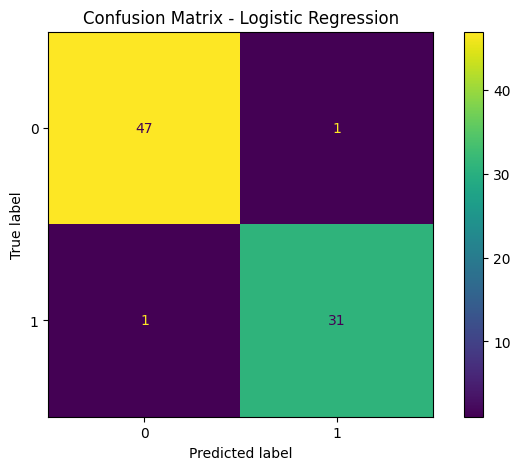

In [ ]:
# Confusion matrix - Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp_lr.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

## 10. Model 2 - Random Forest Classifier

In [ ]:
# =========================
# 10. Random Forest
# =========================
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=8,
        random_state=42
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)

print("Random Forest classification report:")
print(classification_report(y_test, y_pred_rf))

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_logloss = log_loss(y_test, y_prob_rf)

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")
print(f"F1-score: {rf_f1:.4f}")
print(f"Log Loss: {rf_logloss:.4f}")

Random Forest classification report:
              precision    recall  f1-score   support

           0       0.82      0.98      0.90        48
           1       0.96      0.69      0.80        32

    accuracy                           0.86        80
   macro avg       0.89      0.83      0.85        80
weighted avg       0.88      0.86      0.86        80

Accuracy: 0.8625
Precision: 0.9565
Recall: 0.6875
F1-score: 0.8000
Log Loss: 0.3839


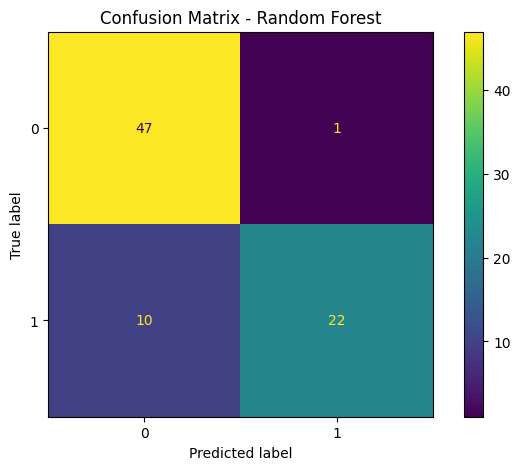

In [ ]:
# Confusion matrix - Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp_rf.plot()
plt.title("Confusion Matrix - Random Forest")
plt.show()

## 11. Compare the two models

The brief asks for a summary table of model evaluation metrics to support the final model choice.

In [ ]:
# =========================
# 11. Model comparison table
# =========================
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall": [lr_recall, rf_recall],
    "F1_Score": [lr_f1, rf_f1],
    "Log_Loss": [lr_logloss, rf_logloss]
})

display(results.sort_values(by="Accuracy", ascending=False))

,Model,Accuracy,Precision,Recall,F1_Score,Log_Loss
0,Logistic Regression,0.9750,0.968750,0.96875,0.96875,0.114179
1,Random Forest,0.8625,0.956522,0.68750,0.80000,0.383858


## 12. Optional fairness check

Because the scenario uses employee characteristics such as gender, age and ethnicity,
it is good practice to inspect outcome rates across groups.
This does **not** prove fairness, but it supports the ethics discussion in the report.

In [ ]:
# =========================
# 12. Simple fairness-style descriptive checks
# =========================
print("Raise rate by gender:")
display(df_clean.groupby("Gender")["Raise"].mean().sort_values(ascending=False))

print("\nRaise rate by ethnicity:")
display(df_clean.groupby("Ethnicity")["Raise"].mean().sort_values(ascending=False))

# Age band example
df_clean["AgeBand"] = pd.cut(
    df_clean["Age"],
    bins=[18, 29, 39, 49, 59, 69],
    labels=["18-29", "30-39", "40-49", "50-59", "60-69"]
)

print("\nRaise rate by age band:")
display(df_clean.groupby("AgeBand", observed=False)["Raise"].mean())

Raise rate by gender:


,Raise
Gender,
Female,0.423529
Male,0.382979
Other,0.352941



Raise rate by ethnicity:


,Raise
Ethnicity,
Black,0.440860
Mixed,0.388889
Asian,0.380952
White,0.367816



Raise rate by age band:


,Raise
AgeBand,
18-29,0.396040
30-39,0.442105
40-49,0.360000
50-59,0.387755
60-69,NaN


## 13. Export cleaned data and model results

This helps if you want tables to paste into Word or use in your appendix.

In [ ]:
# =========================
# 13. Save outputs
# =========================
df_clean.to_csv("Screens4Life_Cleaned_Data.csv")
results.to_csv("Screens4Life_Model_Comparison.csv", index=False)

print("Files saved:")
print("- Screens4Life_Cleaned_Data.csv")
print("- Screens4Life_Model_Comparison.csv")

Files saved:
- Screens4Life_Cleaned_Data.csv
- Screens4Life_Model_Comparison.csv


In [ ]:
# Also save validation outputs for Excel checking
validation_checks.to_csv("Screens4Life_Validation_Checks.csv", index=False)

print("- Screens4Life_Validation_Checks.csv")

- Screens4Life_Validation_Checks.csv


## 14. Short conclusion for your notebook

After running the notebook:
- use the model comparison table to decide which model performs better
- copy charts and key outputs into your report appendix
- discuss ethics, bias risk, maintainability, and business impact in the written report

### Suggested explanation in your report
- Logistic Regression is useful as a transparent baseline.
- Random Forest may perform better when relationships are non-linear.
- The final model should not be chosen on accuracy alone; fairness, interpretability, and governance also matter.

## 15. Maintainability, reusable code, and controlled development

To support continued development and maintenance, this notebook follows several good programming principles:

- **clear section structure** using markdown headings so future users can follow the workflow
- **descriptive variable names** such as `df_clean`, `numeric_cols`, and `validation_checks`
- **reusable logic** for renaming columns, standardising categories, and handling numeric variables
- **pipeline-based modelling**, which reduces the risk of inconsistent preprocessing between training and testing
- **comments and markdown explanations** so the notebook can also be used to train colleagues
- **exported output files** so results can be checked independently

In a real project, controlled development should also include:

- **Git version control** to track code changes and allow rollback
- **peer review** before important HR analytics updates are deployed
- **test cases** for cleaning, feature preparation, and model outputs
- **documentation updates** whenever the workflow or business rules change

These controls improve transparency, reproducibility, and long-term maintainability.